# SATRIA DATA - BIG DATA CHALLENGE (BDC)
## Case 1
##


Kelompok:Tim Anomali SCP-03

Nama Kelompok:
*   Muhamad Nizar Rahman-707012400056
*   Kerin Anggraeni-707012400066
*   Haikal Dwi Anggara-707012400113

# A. Koneksi ke GDrive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# B. Load library dan dataset

In [214]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string

from sklearn.ensemble import GradientBoostingClassifier

In [215]:
#load data
df = pd.read_excel('/content/drive/MyDrive/TIM Anomali SCP-03/Case 1/case_1_labeled_data.xlsx')
# displaying top 10 results
df

,full_text,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep aja anak-anaknya pada jajan lagi daaan ga semua su...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM (Terstruktur-Masif dan Sistempik).,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang-Undang Dasar Negara Republik Indonesia Tahun 1945...,Sasaran Penerima
3,"Makan Bergizi Gratis bikin masyarakat ngerasa diperhatiin, bukan cuma dijanjiin doang https://t....",Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kalau MBG dikritik, jadi bakalan maju terus meski ga ...",Politik
...,...,...
4995,Presiden Prabowo membandingkan program MBG di Brazil yang penerimanya cuman 40 juta anak dengan ...,Anggaran
4996,Gmn MBG disekolah Adik2mu atau Anak2mu..??\nApakah Masih Jalan sampe Hari ini..??\nApakah Menuny...,Distribusi
4997,@tvOneNews Ini org surpa surpe melulu. Rakyat sdh bodo amat sm surpe loe wo @prabowo . Mo 78% k...,Politik
4998,"@ntoirei ambil mbg ajaa, mau dipake kelas 10 mpls",Lainnya


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_text  5000 non-null   object
 1   label      5000 non-null   object
dtypes: object(2)
memory usage: 78.3+ KB


In [ ]:
df['label'].value_counts().sort_index()

,count
label,
Anggaran,727
Distribusi,433
Ekonomi,145
Kualitas Pangan,1247
Lainnya,638
Politik,792
Sasaran Penerima,507
Tata Kelola,511


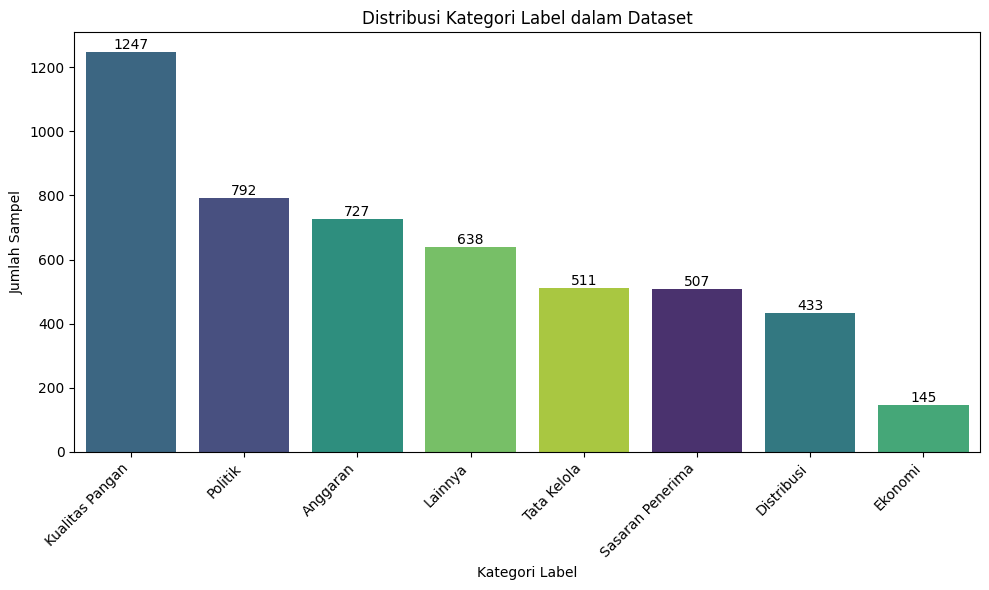

In [ ]:
#import matplotlib.pyplot as plt
#import seaborn as sns

plt.figure(figsize=(10, 6))

order_label = df['label'].value_counts().index

ax = sns.countplot(
    x='label',
    data=df,
    order=order_label,
    hue='label',
    palette='viridis',
    legend=False
)

plt.title('Distribusi Kategori Label dalam Dataset')
plt.xlabel('Kategori Label')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=45, ha='right')

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

# C. Pre-processing

In [ ]:
# Some functions for preprocessing text
# import re
# import string

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers

    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def cleanEmoji(text):
    emoji = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\U0001f926-\U0001f937"
                           u"\U00010000-\U0010ffff"
                           u"\u2640-\u2642"
                           u"\u2600-\u2B55"
                           u"\u200d"
                           u"\u23cf"
                           u"\u23e9"
                           u"\u231a"
                           u"\ufe0f"  # dingbats
                           u"\u3030"
                           "]+", flags=re.UNICODE)
    text = emoji.sub(r'', text)
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

#def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    #text = word_tokenize(text)
    #text = tokenizer.tokenize(text)
    #return text

#def filteringText(text): # Remove stopwors in a text
    #listStopwords = set(stopwords.words('indonesian'))
    #filtered = []
    #for txt in text:
        #if txt not in listStopwords:
            #filtered.append(txt)
    #text = filtered
    #text = filtered
    #return text

#def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    #factory = StemmerFactory()
    #stemmer = factory.create_stemmer()
    #text = [stemmer.stem(word) for word in text]
    #text = [stemmer.stem(word) for word in text]
    #return text

#def toSentence(list_words): # Convert list of words into sentence
    #sentence = ' '.join(word for word in list_words)
    #return sentence

## C1. Cleaning Text & Case Folding

In [ ]:
# Preprocessing data kombinasi kolom content
df['text_clean'] = df['full_text'].apply(cleaningText)
df['text_clean'] = df['text_clean'].apply(casefoldingText)
df['text_clean'] = df['text_clean'].apply(cleanEmoji)
#df.drop(['content'], axis = 1, inplace = True)

df

,full_text,label,text_clean
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima,pret di sekolah gw dapet mbg tetep aja anakana...
1,MBG bentuk penggarongan duit negara secara TSM...,Politik,mbg bentuk penggarongan duit negara secara tsm...
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima,pasal ayat undangundang dasar negara republi...
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima,makan bergizi gratis bikin masyarakat ngerasa ...
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik,presiden ngotot paling sebel kalau mbg dikriti...
...,...,...,...
4995,Presiden Prabowo membandingkan program MBG di ...,Anggaran,presiden prabowo membandingkan program mbg di ...
4996,Gmn MBG disekolah Adik2mu atau Anak2mu..??\nAp...,Distribusi,gmn mbg disekolah adikmu atau anakmu apakah ma...
4997,@tvOneNews Ini org surpa surpe melulu. Rakyat ...,Politik,ini org surpa surpe melulu rakyat sdh bodo ama...
4998,"@ntoirei ambil mbg ajaa, mau dipake kelas 10 mpls",Lainnya,ambil mbg ajaa mau dipake kelas mpls


## C2. Normalisasi kata menggunakan IndoNLP


In [ ]:
!pip install indoNLP

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.9/121.9 kB 5.0 MB/s eta 0:00:00


In [ ]:
# import re
from indoNLP.preprocessing import replace_slang, replace_word_elongation

def normalize_text_keep_mbg(text):
    text = str(text)

    # Lindungi kata mbg supaya tidak diubah oleh indoNLP
    text = re.sub(r'\bmbg\b', 'tokenmbgaman', text, flags=re.IGNORECASE)

    # Normalisasi umum
    text = replace_word_elongation(text)
    text = replace_slang(text)

    # Kembalikan token khusus menjadi mbg
    text = re.sub(r'\btokenmbgaman\b', 'mbg', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
df['text_normalized'] = df['text_clean'].apply(normalize_text_keep_mbg)

df[['full_text','text_clean', 'text_normalized', 'label']].head()

,full_text,text_clean,text_normalized,label
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,pret di sekolah gw dapet mbg tetep aja anakana...,pret di sekolah gue dapat mbg tetap saja anaka...,Sasaran Penerima
1,MBG bentuk penggarongan duit negara secara TSM...,mbg bentuk penggarongan duit negara secara tsm...,mbg bentuk penggarongan duit negara secara tsm...,Politik
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,pasal ayat undangundang dasar negara republi...,pasal ayat undangundang dasar negara republik ...,Sasaran Penerima
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,makan bergizi gratis bikin masyarakat ngerasa ...,makan bergizi gratis bikin masyarakat merasa d...,Sasaran Penerima
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",presiden ngotot paling sebel kalau mbg dikriti...,presiden ngotot paling sebel kalau mbg dikriti...,Politik


In [ ]:
df

,full_text,label,text_clean,text_normalized
0,@ARSIPAJA Pret. Di sekolah gw dapet MBG tetep ...,Sasaran Penerima,pret di sekolah gw dapet mbg tetep aja anakana...,pret di sekolah gue dapat mbg tetap saja anaka...
1,MBG bentuk penggarongan duit negara secara TSM...,Politik,mbg bentuk penggarongan duit negara secara tsm...,mbg bentuk penggarongan duit negara secara tsm...
2,@inzhapt_76 @ARSIPAJA Pasal 34 ayat (1) Undang...,Sasaran Penerima,pasal ayat undangundang dasar negara republi...,pasal ayat undangundang dasar negara republik ...
3,Makan Bergizi Gratis bikin masyarakat ngerasa ...,Sasaran Penerima,makan bergizi gratis bikin masyarakat ngerasa ...,makan bergizi gratis bikin masyarakat merasa d...
4,"@OniSuryaman Presiden ngotot, paling sebel kal...",Politik,presiden ngotot paling sebel kalau mbg dikriti...,presiden ngotot paling sebel kalau mbg dikriti...
...,...,...,...,...
4995,Presiden Prabowo membandingkan program MBG di ...,Anggaran,presiden prabowo membandingkan program mbg di ...,presiden prabowo membandingkan program mbg di ...
4996,Gmn MBG disekolah Adik2mu atau Anak2mu..??\nAp...,Distribusi,gmn mbg disekolah adikmu atau anakmu apakah ma...,bagaimana mbg disekolah adikmu atau anakmu apa...
4997,@tvOneNews Ini org surpa surpe melulu. Rakyat ...,Politik,ini org surpa surpe melulu rakyat sdh bodo ama...,ini orang surpa surpe melulu rakyat sudah bodo...
4998,"@ntoirei ambil mbg ajaa, mau dipake kelas 10 mpls",Lainnya,ambil mbg ajaa mau dipake kelas mpls,ambil mbg saja mau dipakai kelas mpls


In [ ]:
df[['text_clean', 'text_normalized']].sample(10)

,text_clean,text_normalized
3979,mbg demi generasi sehat dan cerdas,mbg demi generasi sehat dan cerdas
2444,mbg pembunuh massal hasan,mbg pembunuh massal hasan
3735,how come ya biar keliatan kerja dan bos senan...,how come ya biar kelihatan kerja dan bos senan...
4293,mbg makanan bergizi rebu,mbg makanan bergizi rebu
1264,mbg di sini kata adek gue yang enak cuma katsu...,mbg di sini kata adek gue yang enak cuma katsu...
4727,anggarannya kan kena efisiensi buat mbg sama d...,anggarannya kan kena efisiensi buat mbg sama d...
3361,kalau kata kppu sih masalah mbg itu di tantang...,kalau kata kppu sih masalah mbg itu di tantang...
4622,redsindo buat mbg biar terlaksana sama u know ...,redsindo buat mbg biar terlaksana sama lu know...
610,padahal dia yang memiskinkan dan membodohkan d...,padahal dia yang memiskinkan dan membodohkan d...
2761,dari awal aku sdh bilang mbg itu hy lumbung ko...,dari awal aku sudah bilang mbg itu hai lumbung...


## C3. Tokenisasi & Vektorisasi menggunakan Indobert

In [ ]:
!pip install transformers -q

In [ ]:
#import pandas as pd
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df['text_input'] = df['text_normalized'].fillna('').astype(str)

In [ ]:
label_encoder = LabelEncoder()

df['label_id'] = label_encoder.fit_transform(df['label'])

df[['label', 'label_id']].drop_duplicates().sort_values('label_id')

,label,label_id
7,Anggaran,0
6,Distribusi,1
8,Ekonomi,2
5,Kualitas Pangan,3
11,Lainnya,4
1,Politik,5
0,Sasaran Penerima,6
23,Tata Kelola,7


In [ ]:
from sklearn.model_selection import train_test_split

label_df = df['label_id']
fitur_df = df['text_input']

# 70% train, 30% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    fitur_df,
    label_df,
    test_size=0.3,
    random_state=42,
    stratify=label_df
)

# Dari 30% sementara, dibagi menjadi 15% validation dan 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [ ]:
# coba kita lihat berapa jumlah data latih dan data ujinya
print("Banyak data latih (fitur) setelah dilakukan Train-Test Split: ", len(X_train))
print("Banyak data latih (label) setelah dilakukan Train-Test Split: ", len(y_train))
print("Banyak data uji sementara (fitur) setelah dilakukan Train-Test Split: ", len(X_temp))
print("Banyak data uji sementara (label) setelah dilakukan Train-Test Split: ", len(y_temp))

print("Banyak data validasi (fitur) setelah dilakukan Train-Test Split: ", len(X_val))
print("Banyak data validasi (label) setelah dilakukan Train-Test Split: ", len(y_val))
print("Banyak data validasi (fitur) setelah dilakukan Train-Test Split: ", len(X_test))
print("Banyak data validasi (label) setelah dilakukan Train-Test Split: ", len(y_test))

Banyak data latih (fitur) setelah dilakukan Train-Test Split:  3500
Banyak data latih (label) setelah dilakukan Train-Test Split:  3500
Banyak data uji sementara (fitur) setelah dilakukan Train-Test Split:  1500
Banyak data uji sementara (label) setelah dilakukan Train-Test Split:  1500
Banyak data validasi (fitur) setelah dilakukan Train-Test Split:  750
Banyak data validasi (label) setelah dilakukan Train-Test Split:  750
Banyak data validasi (fitur) setelah dilakukan Train-Test Split:  750
Banyak data validasi (label) setelah dilakukan Train-Test Split:  750


In [ ]:
print("Jumlah data train:", len(X_train))
print("Jumlah data test:", len(X_test))

Jumlah data train: 3500
Jumlah data test: 750


In [ ]:
print("Distribusi train:")
print(y_train.value_counts().sort_index())

print("\nDistribusi test:")
print(y_test.value_counts().sort_index())

Distribusi train:
label_id
0    509
1    303
2    101
3    873
4    447
5    554
6    355
7    358
Name: count, dtype: int64

Distribusi test:
label_id
0    109
1     65
2     22
3    187
4     96
5    119
6     76
7     76
Name: count, dtype: int64


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
idx = 0

print("Teks asli:")
print(X_train.iloc[idx])

print("\nInput IDs:")
print(train_encodings['input_ids'][idx])

print("\nAttention Mask:")
print(train_encodings['attention_mask'][idx])

Teks asli:
rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan untuk rakyat kisminjudulnya saja mbg tapi prakteknya bagi² fe proyekmemang enak duit korupsi berjamaah itugak kerja tapi dapat jatahitu baru mbgblm proyek lain

Input IDs:
[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, 90, 1829, 5382, 1193, 21789, 57, 377, 2201, 30365, 469, 19982, 1, 6517, 2843, 21143, 3107, 7882, 3921, 19496, 137, 1890, 494, 469, 173, 14399, 231, 440, 2201, 6448, 8482, 2843, 245, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][idx])

print("\nTokens:")
print(tokens)


Tokens:
['[CLS]', 'rendahnya', 'sdm', 'akibat', 'dari', 'rendahnya', 'pola', 'tata', 'kelola', 'pemerintahan', 'anggaran', 'tidak', 'dim', '##ks', '##im', '##l', '##kan', 'untuk', 'rakyat', 'kis', '##min', '##judul', '##nya', 'saja', 'mb', '##g', 'tapi', 'prakteknya', '[UNK]', 'fe', 'proyek', '##memang', 'enak', 'duit', 'korupsi', 'berjamaah', 'itu', '##gak', 'kerja', 'tapi', 'dapat', 'jatah', '##itu', 'baru', 'mb', '##gb', '##lm', 'proyek', 'lain', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
idx = 0

print("Teks asli:")
print(X_train.iloc[idx])

print("\nTokens:")
print(tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][idx]))

print("\nInput IDs:")
print(train_encodings['input_ids'][idx])

print("\nAttention Mask:")
print(train_encodings['attention_mask'][idx])

Teks asli:
rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan untuk rakyat kisminjudulnya saja mbg tapi prakteknya bagi² fe proyekmemang enak duit korupsi berjamaah itugak kerja tapi dapat jatahitu baru mbgblm proyek lain

Tokens:
['[CLS]', 'rendahnya', 'sdm', 'akibat', 'dari', 'rendahnya', 'pola', 'tata', 'kelola', 'pemerintahan', 'anggaran', 'tidak', 'dim', '##ks', '##im', '##l', '##kan', 'untuk', 'rakyat', 'kis', '##min', '##judul', '##nya', 'saja', 'mb', '##g', 'tapi', 'prakteknya', '[UNK]', 'fe', 'proyek', '##memang', 'enak', 'duit', 'korupsi', 'berjamaah', 'itu', '##gak', 'kerja', 'tapi', 'dapat', 'jatah', '##itu', 'baru', 'mb', '##gb', '##lm', 'proyek', 'lain', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Input IDs:
[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, 90, 1829, 5382, 1193

In [ ]:
import pandas as pd

tokenized_train_df = pd.DataFrame({
    'text': X_train.reset_index(drop=True),
    'label_id': y_train.reset_index(drop=True),
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask']
})

# Tambahkan bentuk token
tokenized_train_df['tokens'] = tokenized_train_df['input_ids'].apply(
    lambda x: tokenizer.convert_ids_to_tokens(x)
)

tokenized_train_df.head()

,text,label_id,input_ids,attention_mask,tokens
0,rendahnya sdm akibat dari rendahnya pola tata ...,7,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], rendahnya, sdm, akibat, dari, rendahny..."
1,kampung makin kesini mereka makin tidak peduli...,0,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], kampung, makin, kesini, mereka, makin,..."
2,program mbg seharusnya menjadi layanan publik ...,7,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 9...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], program, mb, ##g, seharusnya, menjadi,..."
3,konsep mbg yang real kan memang implikasinya k...,7,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 168...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[CLS], konsep, mb, ##g, yang, real, kan, mema..."
4,program mbg akan menjamah ke seluruh pelosok p...,1,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...","[[CLS], program, mb, ##g, akan, menjam, ##ah, ..."


In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', 100)

def make_encoding_dataframe(df, X_split, y_split, encodings, split_name):
    # Ambil data asli berdasarkan index X_split
    temp_df = df.loc[X_split.index, [
        'full_text',
        'text_clean',
        'text_normalized',
        'text_input',
        'label',
        'label_id'
    ]].reset_index()

    temp_df = temp_df.rename(columns={'index': 'original_index'})

    # Tambahkan hasil encoding IndoBERT
    temp_df['split'] = split_name
    temp_df['input_ids'] = encodings['input_ids']
    temp_df['attention_mask'] = encodings['attention_mask']

    # Kalau ada token_type_ids, tambahkan juga
    if 'token_type_ids' in encodings:
        temp_df['token_type_ids'] = encodings['token_type_ids']

    # Ubah input_ids menjadi token/subword
    temp_df['tokens'] = temp_df['input_ids'].apply(
        lambda x: tokenizer.convert_ids_to_tokens(x)
    )

    return temp_df

In [ ]:
train_encoding_df = make_encoding_dataframe(
    df, X_train, y_train, train_encodings, 'train'
)

val_encoding_df = make_encoding_dataframe(
    df, X_val, y_val, val_encodings, 'validation'
)

test_encoding_df = make_encoding_dataframe(
    df, X_test, y_test, test_encodings, 'test'
)

In [ ]:
train_encoding_df.head()

,original_index,full_text,text_clean,text_normalized,text_input,label,label_id,split,input_ids,attention_mask,token_type_ids,tokens
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,train,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,train,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,train,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,train,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,train,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
train_encoding_df[[
    'original_index',
    'full_text',
    'text_clean',
    'text_normalized',
    'label',
    'label_id',
    'tokens',
    'input_ids',
    'attention_mask'
]].head()

,original_index,full_text,text_clean,text_normalized,label,label_id,tokens,input_ids,attention_mask
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,"[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid...","[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,"[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ...","[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,"[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men...","[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,"[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ...","[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,"[[CLS], program, mb, ##g, akan, menjam, ##ah, ke, seluruh, pelosok, papua, [SEP], [PAD], [PAD], ...","[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
all_encoding_df = pd.concat(
    [train_encoding_df, val_encoding_df, test_encoding_df],
    ignore_index=True
)

all_encoding_df.head()

,original_index,full_text,text_clean,text_normalized,text_input,label,label_id,split,input_ids,attention_mask,token_type_ids,tokens
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,train,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,train,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,train,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,train,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,train,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
idx = 0

token_detail_df = pd.DataFrame({
    'token': train_encoding_df.loc[idx, 'tokens'],
    'input_id': train_encoding_df.loc[idx, 'input_ids'],
    'attention_mask': train_encoding_df.loc[idx, 'attention_mask']
})

token_detail_df = token_detail_df[token_detail_df['attention_mask'] == 1].reset_index(drop=True)

token_detail_df

,token,input_id,attention_mask
0,[CLS],2,1
1,rendahnya,11700,1
2,sdm,6233,1
3,akibat,1597,1
4,dari,98,1
5,rendahnya,11700,1
6,pola,2581,1
7,tata,2816,1
8,kelola,13496,1
9,pemerintahan,2395,1


In [ ]:
# Simpan dataframe ke file Excel
all_encoding_df.to_excel('/content/drive/MyDrive/TIM Anomali SCP-03/Case 1/hasil_encoding_indobert.xlsx', index=False)

# D. Model Transformed Based

## D.1 Install & Import

In [ ]:
!pip install transformers -q

import torch
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.preprocessing import LabelEncoder

## D.2 Encode label

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label_id'] = label_encoder.fit_transform(df['label'])

## D.3 Train test split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    df['full_text'].astype(str),
    df['label_id'],
    test_size=0.2,
    random_state=42,
    stratify=df['label_id']
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

## D.4 Load tokenizer IndoBERT

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

## D.5 Tokenisasi

In [ ]:
train_encodings = tokenizer(list(X_train), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(X_val), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(X_test), truncation=True, padding=True, max_length=128)

## D.6 Dataset Class

In [ ]:
import torch

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

## D.7 Buat Dataset

In [ ]:
train_dataset = Dataset(train_encodings, y_train.tolist())
val_dataset = Dataset(val_encodings, y_val.tolist())
test_dataset = Dataset(test_encodings, y_test.tolist())

## D.8 Load IndoBERT Model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p1",
    num_labels=len(label_encoder.classes_)
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## D.9 Training Argument

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    logging_steps=10
)

## D.10 Trainer

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

## D.11 Train Model

In [ ]:
trainer.train()

Step,Training Loss
10,0.951977
20,0.962373
30,1.000583
40,0.737587
50,0.882890
60,0.807742
70,0.819085
80,0.733026
90,0.769560
100,0.717004


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=750, training_loss=0.5245825403531392, metrics={'train_runtime': 302.3846, 'train_samples_per_second': 39.685, 'train_steps_per_second': 2.48, 'total_flos': 797795696050176.0, 'train_loss': 0.5245825403531392, 'epoch': 3.0})

## D.12 Evaluasi

In [ ]:
trainer.evaluate()

{'eval_loss': 1.644323468208313,
 'eval_runtime': 3.5898,
 'eval_samples_per_second': 139.282,
 'eval_steps_per_second': 8.914,
 'epoch': 3.0}

## D.13 Prediksi

In [ ]:
pred = trainer.predict(test_dataset)
y_pred = pred.predictions.argmax(axis=1)

## D.14 Hitung Balanced Accuracy

In [ ]:
from sklearn.metrics import balanced_accuracy_score
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced Accuracy:", balanced_acc)

Balanced Accuracy: 0.5538227266681867


## D.15 Classification report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        72
           1       0.68      0.63      0.65        43
           2       0.29      0.13      0.18        15
           3       0.68      0.66      0.67       125
           4       0.58      0.59      0.59        64
           5       0.60      0.61      0.60        80
           6       0.54      0.62      0.58        50
           7       0.41      0.45      0.43        51

    accuracy                           0.61       500
   macro avg       0.56      0.55      0.55       500
weighted avg       0.61      0.61      0.61       500



#E. Gradient Boosting

##E.1 Label Encoding


In [216]:
# FEATURE DAN LABEL

X = df['full_text']

y = df['label']

# LABEL ENCODING

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size = 0.2,
    random_state = 42

)

##E.2 TF - IDF

In [218]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(

    max_features = 5000

)

X_train = tfidf.fit_transform(X_train)

X_test = tfidf.transform(X_test)

In [219]:
X_train = X_train.toarray()

X_test = X_test.toarray()

##E.3 Training Gradient Boosting

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()

gb_model.fit(X_train, y_train)

GradientBoostingClassifier()

Prediction

In [ ]:
y_pred = gb_model.predict(X_test)

##E.4 Balanced Scrore

In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(

    y_test,
    y_pred

)

print("Balanced Accuracy Score :", balanced_acc)

Balanced Accuracy Score : 0.5047978485492244


##E.5 Clasification Report

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print(classification_report(y_test, y_pred))

Accuracy : 0.548
              precision    recall  f1-score   support

           0       0.65      0.69      0.67       146
           1       0.56      0.34      0.42        92
           2       0.71      0.52      0.60        29
           3       0.54      0.74      0.63       258
           4       0.47      0.54      0.50       123
           5       0.48      0.41      0.45       147
           6       0.58      0.47      0.52       105
           7       0.51      0.33      0.40       100

    accuracy                           0.55      1000
   macro avg       0.56      0.50      0.52      1000
weighted avg       0.55      0.55      0.54      1000



##E.6 Confusion Matrix

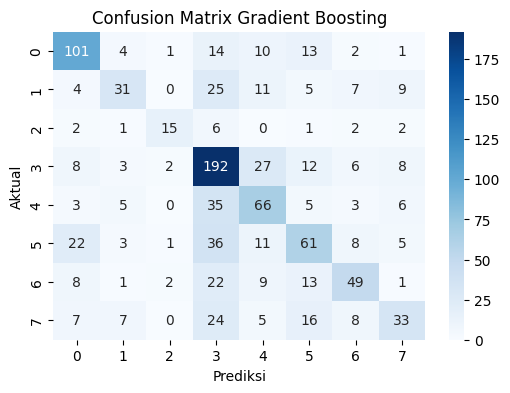

In [ ]:


from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

# hitung confusion matrix

cm = confusion_matrix(y_test, y_pred)

# plot

plt.figure(figsize=(6, 4))

sns.heatmap(

    cm,
    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.xlabel('Prediksi')

plt.ylabel('Aktual')

plt.title('Confusion Matrix Gradient Boosting')

plt.show()

#F. Optimasi: Hyperparameter Tuning dengan Gridserch CV

## F1. Tahap 1: Pencarian parameter yang optimal

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {

    'n_estimators': [50],
    'learning_rate': [0.1],
    'max_depth': [3],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2]

}

In [ ]:
# Buat Model Gradient BoostinG
gb_model = GradientBoostingClassifier(
    random_state = 42

)

## F2. Tahap 2: Proses Hyperparameter Optimization (HPO)

In [ ]:
grid_search = GridSearchCV(
    estimator = gb_model,
    param_grid = param_grid,
    cv = 3,
    scoring = 'accuracy',
    n_jobs = -1,
    verbose = 2
)

## F3. Tahap 3: Training HPO

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3, estimator=GradientBoostingClassifier(random_state=42),
             n_jobs=-1,
             param_grid={'learning_rate': [0.1], 'max_depth': [3],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 4], 'n_estimators': [50]},
             scoring='accuracy', verbose=2)

In [ ]:
# Ambil Parameter Terbaik
print("Best Parameters : ", grid_search.best_params_)

print("Best Score : ", grid_search.best_score_)

Best Parameters :  {'learning_rate': 0.1, 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best Score :  0.5092481891087465


In [ ]:
best_gb_model = grid_search.best_estimator_

In [ ]:
y_pred_hpo = best_gb_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_hpo = accuracy_score(

    y_test,
    y_pred_hpo

)

print("Accuracy Setelah HPO :", accuracy_hpo)

Accuracy Setelah HPO : 0.528


## F4. Tahap 4: Balanced Accuracy Setelah HPO

In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc_hpo = balanced_accuracy_score(

    y_test,
    y_pred_hpo

)

print("Balanced Accuracy Setelah HPO :", balanced_acc_hpo)

Balanced Accuracy Setelah HPO : 0.4808064902727992


## F5. Tahap 5: Classification Report Setelah HPO

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(

    y_test,
    y_pred_hpo

))

              precision    recall  f1-score   support

           0       0.65      0.65      0.65       146
           1       0.65      0.28      0.39        92
           2       0.61      0.48      0.54        29
           3       0.50      0.74      0.60       258
           4       0.45      0.54      0.49       123
           5       0.48      0.39      0.43       147
           6       0.61      0.45      0.52       105
           7       0.49      0.31      0.38       100

    accuracy                           0.53      1000
   macro avg       0.56      0.48      0.50      1000
weighted avg       0.54      0.53      0.52      1000



## F6. Tahap 6: Confusion Matrix Setelah HPO

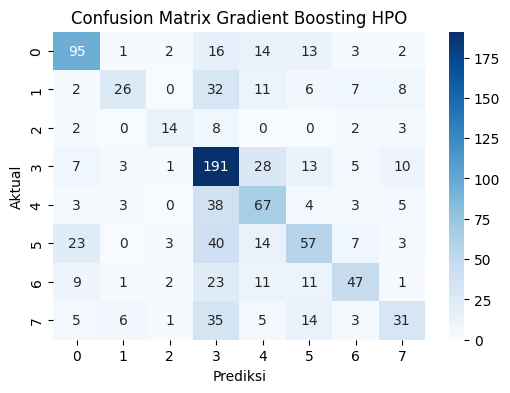

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    y_test,
    y_pred_hpo
)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'

)

plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Gradient Boosting HPO')
plt.show()

#DATASET 2

In [ ]:
#load data
df = pd.read_excel('/content/drive/MyDrive/TIM Anomali SCP-03/Case 1/case_1_text_to_predict.xlsx')
# displaying top 10 results
df

,id,full_text
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ada yg dpt malahan🤧
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat mbg baru beberapa sekokah ˙𐃷˙
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah dapat MBG dan masakan MBG asal gak enak anak aja sa..."
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sasaran Ibu Hamil &amp; Balita https://t.co/bKoVA6Unne"
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo
...,...,...
1495,TXT1496,"Usut punya usut, katanya dia lagi nyoba supplier baru, dan ternyata hasilnya sub-optimal.\n \nSi..."
1496,TXT1497,@txtdrimedia Jadi tujuan MBG agar anak kuat racun dalam makanan yah... 😅
1497,TXT1498,"Program MBG di Kabupaten Magetan Butuh 30 Dapur, Baru Tersedia 9 Dapur. https://t.co/EGRAQMvfDU"
1498,TXT1499,mbg fish n chip+roti+susu+pisang kenyangpol🤤🤤🤤


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1500 non-null   object
 1   full_text  1500 non-null   object
dtypes: object(2)
memory usage: 23.6+ KB


Pre Processing

In [ ]:
# Some functions for preprocessing text
# import re
# import string

def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # remove mentions
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # remove hashtag
    text = re.sub(r'RT[\s]', '', text) # remove RT
    text = re.sub(r"http\S+", '', text) # remove link
    text = re.sub(r'[0-9]+', '', text) # remove numbers

    text = text.replace('\n', ' ') # replace new line into space
    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuations
    text = text.strip(' ') # remove characters space from both left and right text
    return text

def cleanEmoji(text):
    emoji = re.compile("["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"
                           u"\U000024C2-\U0001F251"
                           u"\U0001f926-\U0001f937"
                           u"\U00010000-\U0010ffff"
                           u"\u2640-\u2642"
                           u"\u2600-\u2B55"
                           u"\u200d"
                           u"\u23cf"
                           u"\u23e9"
                           u"\u231a"
                           u"\ufe0f"  # dingbats
                           u"\u3030"
                           "]+", flags=re.UNICODE)
    text = emoji.sub(r'', text)
    return text

def casefoldingText(text): # Converting all the characters in a text into lower case
    text = text.lower()
    return text

#def tokenizingText(text): # Tokenizing or splitting a string, text into a list of tokens
    #text = word_tokenize(text)
    #text = tokenizer.tokenize(text)
    #return text

#def filteringText(text): # Remove stopwors in a text
    #listStopwords = set(stopwords.words('indonesian'))
    #filtered = []
    #for txt in text:
        #if txt not in listStopwords:
            #filtered.append(txt)
    #text = filtered
    #text = filtered
    #return text

#def stemmingText(text): # Reducing a word to its word stem that affixes to suffixes and prefixes or to the roots of words
    #factory = StemmerFactory()
    #stemmer = factory.create_stemmer()
    #text = [stemmer.stem(word) for word in text]
    #text = [stemmer.stem(word) for word in text]
    #return text

#def toSentence(list_words): # Convert list of words into sentence
    #sentence = ' '.join(word for word in list_words)
    #return sentence

Cleaning

In [ ]:
# Preprocessing data kombinasi kolom content
df['text_clean'] = df['full_text'].apply(cleaningText)
df['text_clean'] = df['text_clean'].apply(casefoldingText)
df['text_clean'] = df['text_clean'].apply(cleanEmoji)
#df.drop(['content'], axis = 1, inplace = True)

df

,id,full_text,text_clean
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ada yg dpt malahan🤧,mbg di sekolah kota saya belum ada yg dpt malahan
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat mbg baru beberapa sekokah ˙𐃷˙,wkwkkdidaerah ku pun yg dapat mbg baru beberapa sekokah ˙˙
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah dapat MBG dan masakan MBG asal gak enak anak aja sa...",tai tau enggak gak semua sekolah dapat mbg dan masakan mbg asal gak enak anak aja sampai gak ma...
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sasaran Ibu Hamil &amp; Balita https://t.co/bKoVA6Unne",gencar cegah stunting mbg telah capai sasaran ibu hamil amp balita
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo,siswa kupang keracunan program mbg
...,...,...,...
1495,TXT1496,"Usut punya usut, katanya dia lagi nyoba supplier baru, dan ternyata hasilnya sub-optimal.\n \nSi...",usut punya usut katanya dia lagi nyoba supplier baru dan ternyata hasilnya suboptimal singkatn...
1496,TXT1497,@txtdrimedia Jadi tujuan MBG agar anak kuat racun dalam makanan yah... 😅,jadi tujuan mbg agar anak kuat racun dalam makanan yah
1497,TXT1498,"Program MBG di Kabupaten Magetan Butuh 30 Dapur, Baru Tersedia 9 Dapur. https://t.co/EGRAQMvfDU",program mbg di kabupaten magetan butuh dapur baru tersedia dapur
1498,TXT1499,mbg fish n chip+roti+susu+pisang kenyangpol🤤🤤🤤,mbg fish n chiprotisusupisang kenyangpol


##Normalisasi

In [ ]:
!pip install indoNLP

In [ ]:
# import re
from indoNLP.preprocessing import replace_slang, replace_word_elongation

def normalize_text_keep_mbg(text):
    text = str(text)

    # Lindungi kata mbg supaya tidak diubah oleh indoNLP
    text = re.sub(r'\bmbg\b', 'tokenmbgaman', text, flags=re.IGNORECASE)

    # Normalisasi umum
    text = replace_word_elongation(text)
    text = replace_slang(text)

    # Kembalikan token khusus menjadi mbg
    text = re.sub(r'\btokenmbgaman\b', 'mbg', text)

    # Rapikan spasi
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [ ]:
df2['text_normalized'] = df2['text_clean'].apply(normalize_text_keep_mbg)

df2[['full_text','text_clean', 'text_normalized']].head()

,full_text,text_clean,text_normalized
0,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...
1,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...
2,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...
3,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...
4,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua


In [ ]:
df

,id,full_text,text_clean,text_normalized
0,TXT0001,@yeahhhmaybe mbg di sekolah kota saya belum ada yg dpt malahan🤧,mbg di sekolah kota saya belum ada yg dpt malahan,mbg di sekolah kota saya belum ada yang dapat malahan
1,TXT0002,@thefineshytguy WKWKKdidaerah ku pun yg dapat mbg baru beberapa sekokah ˙𐃷˙,wkwkkdidaerah ku pun yg dapat mbg baru beberapa sekokah ˙˙,wkwkkdidaerah ku pun yang dapat mbg baru beberapa sekokah ˙˙
2,TXT0003,"@ARSIPAJA Tai tau enggak ,gak semua sekolah dapat MBG dan masakan MBG asal gak enak anak aja sa...",tai tau enggak gak semua sekolah dapat mbg dan masakan mbg asal gak enak anak aja sampai gak ma...,tahi tau enggak enggak semua sekolah dapat mbg dan masakan mbg asal enggak enak anak saja sampai...
3,TXT0004,"Gencar Cegah Stunting, MBG Telah Capai 49% Sasaran Ibu Hamil &amp; Balita https://t.co/bKoVA6Unne",gencar cegah stunting mbg telah capai sasaran ibu hamil amp balita,gencar cegah stunting mbg telah capai sasaran ibu hamil amp balita
4,TXT0005,140 siswa kupang Keracunan program MBG @prabowo,siswa kupang keracunan program mbg,siswa kupang keracunan program mbg
...,...,...,...,...
1495,TXT1496,"Usut punya usut, katanya dia lagi nyoba supplier baru, dan ternyata hasilnya sub-optimal.\n \nSi...",usut punya usut katanya dia lagi nyoba supplier baru dan ternyata hasilnya suboptimal singkatn...,usut punya usut katanya dia lagi mencoba supplier baru dan ternyata hasilnya suboptimal singkatn...
1496,TXT1497,@txtdrimedia Jadi tujuan MBG agar anak kuat racun dalam makanan yah... 😅,jadi tujuan mbg agar anak kuat racun dalam makanan yah,jadi tujuan mbg agar anak kuat racun dalam makanan ya
1497,TXT1498,"Program MBG di Kabupaten Magetan Butuh 30 Dapur, Baru Tersedia 9 Dapur. https://t.co/EGRAQMvfDU",program mbg di kabupaten magetan butuh dapur baru tersedia dapur,program mbg di kabupaten magetan butuh dapur baru tersedia dapur
1498,TXT1499,mbg fish n chip+roti+susu+pisang kenyangpol🤤🤤🤤,mbg fish n chiprotisusupisang kenyangpol,mbg fish n chiprotisusupisang kenyangpol


In [ ]:
df[['text_clean', 'text_normalized']].sample(10)

,text_clean,text_normalized
611,ini bisa dibilang salah satu dampak serius dari mbg bahkan di rancangan terbaru anggaran mbg leb...,ini bisa dibilang salah satu dampak serius dari mbg bahkan di rancangan terbaru anggaran mbg leb...
761,apain mbg tidak bisa menambah kecerdasan tambah gendut bisa,apai mbg tidak bisa menambah kecerdasan tambah gendut bisa
1419,setidaknya kalau anies atau ganjar yang naik kaga bakalan ada program gajetot kayak mbg,setidaknya kalau anies atau ganjar yang naik kagak bakalan ada program gajetot kayak mbg
560,mbg ini didistribusikan denan anaknya atau ortunya datang kesekolah mengambil jatah menu mbg mas...,mbg ini didistribusikan denan anaknya atau orang tuanya datang kesekolah mengambil jatah menu mb...
1043,dipikir org org bakal mati kali ya klo ngga dpt mbg,dipikir orang orang bakal mati kali ya kalo enggak dapat mbg
513,uncover makan bergizi gratis bakteri ecoli,uncover makan bergizi gratis bakteri ecoli
1060,makan bergizi gratis,makan bergizi gratis
734,yantie apakah koordinator bgn di daerah berani ambil langkah sendiri tanpa setoran keatas kenap...,yantie apakah koordinator bgn di daerah berani ambil langkah sendiri tanpa setoran keatas kenapa...
835,mulai dari mbgsekolah rakyatkoperasi merah putihgiant sea wallsemua pake dana trilyunanyg pentin...,mulai dari mbgsekolah rakyatkoperasi merah putihgiant sea wallsemua pakai dana trilyunanyg penti...
1469,mbg bukan sekadar program tapi bentuk kepedulian yang makin detail,mbg bukan sekadar program tapi bentuk kepedulian yang makin detail


##Tokenisasi

In [ ]:
!pip install transformers -q

In [ ]:
#import pandas as pd
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df['text_input'] = df['full_text'].fillna('').astype(str)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p1")

In [ ]:
train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

val_encodings = tokenizer(
    X_val.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
idx = 0

print("Teks asli:")
print(X_train.iloc[idx])

print("\nInput IDs:")
print(train_encodings['input_ids'][idx])

print("\nAttention Mask:")
print(train_encodings['attention_mask'][idx])

Teks asli:
rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan untuk rakyat kisminjudulnya saja mbg tapi prakteknya bagi² fe proyekmemang enak duit korupsi berjamaah itugak kerja tapi dapat jatahitu baru mbgblm proyek lain

Input IDs:
[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, 90, 1829, 5382, 1193, 21789, 57, 377, 2201, 30365, 469, 19982, 1, 6517, 2843, 21143, 3107, 7882, 3921, 19496, 137, 1890, 494, 469, 173, 14399, 231, 440, 2201, 6448, 8482, 2843, 245, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Attention Mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [ ]:
tokens = tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][idx])

print("\nTokens:")
print(tokens)


Tokens:
['[CLS]', 'rendahnya', 'sdm', 'akibat', 'dari', 'rendahnya', 'pola', 'tata', 'kelola', 'pemerintahan', 'anggaran', 'tidak', 'dim', '##ks', '##im', '##l', '##kan', 'untuk', 'rakyat', 'kis', '##min', '##judul', '##nya', 'saja', 'mb', '##g', 'tapi', 'prakteknya', '[UNK]', 'fe', 'proyek', '##memang', 'enak', 'duit', 'korupsi', 'berjamaah', 'itu', '##gak', 'kerja', 'tapi', 'dapat', 'jatah', '##itu', 'baru', 'mb', '##gb', '##lm', 'proyek', 'lain', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']


In [ ]:
idx = 0

print("Teks asli:")
print(X_train.iloc[idx])

print("\nTokens:")
print(tokenizer.convert_ids_to_tokens(train_encodings['input_ids'][idx]))

print("\nInput IDs:")
print(train_encodings['input_ids'][idx])

print("\nAttention Mask:")
print(train_encodings['attention_mask'][idx])

Teks asli:
rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan untuk rakyat kisminjudulnya saja mbg tapi prakteknya bagi² fe proyekmemang enak duit korupsi berjamaah itugak kerja tapi dapat jatahitu baru mbgblm proyek lain

Tokens:
['[CLS]', 'rendahnya', 'sdm', 'akibat', 'dari', 'rendahnya', 'pola', 'tata', 'kelola', 'pemerintahan', 'anggaran', 'tidak', 'dim', '##ks', '##im', '##l', '##kan', 'untuk', 'rakyat', 'kis', '##min', '##judul', '##nya', 'saja', 'mb', '##g', 'tapi', 'prakteknya', '[UNK]', 'fe', 'proyek', '##memang', 'enak', 'duit', 'korupsi', 'berjamaah', 'itu', '##gak', 'kerja', 'tapi', 'dapat', 'jatah', '##itu', 'baru', 'mb', '##gb', '##lm', 'proyek', 'lain', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

Input IDs:
[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, 90, 1829, 5382, 1193

In [ ]:
import pandas as pd

tokenized_train_df = pd.DataFrame({
    'text': X_train.reset_index(drop=True),
    'label_id': y_train.reset_index(drop=True),
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask']
})

# Tambahkan bentuk token
tokenized_train_df['tokens'] = tokenized_train_df['input_ids'].apply(
    lambda x: tokenizer.convert_ids_to_tokens(x)
)

tokenized_train_df.head()

,text,label_id,input_ids,attention_mask,tokens
0,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,7,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid..."
1,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,0,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ..."
2,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,7,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,...","[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men..."
3,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,7,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ..."
4,program mbg akan menjamah ke seluruh pelosok papua,1,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], program, mb, ##g, akan, menjam, ##ah, ke, seluruh, pelosok, papua, [SEP], [PAD], [PAD], ..."


In [ ]:
import pandas as pd

pd.set_option('display.max_colwidth', 100)

def make_encoding_dataframe(df, X_split, y_split, encodings, split_name):
    # Ambil data asli berdasarkan index X_split
    temp_df = df.loc[X_split.index, [
        'full_text',
        'text_clean',
        'text_normalized',
        'text_input',
        'label',
        'label_id'
    ]].reset_index()

    temp_df = temp_df.rename(columns={'index': 'original_index'})

    # Tambahkan hasil encoding IndoBERT
    temp_df['split'] = split_name
    temp_df['input_ids'] = encodings['input_ids']
    temp_df['attention_mask'] = encodings['attention_mask']

    # Kalau ada token_type_ids, tambahkan juga
    if 'token_type_ids' in encodings:
        temp_df['token_type_ids'] = encodings['token_type_ids']

    # Ubah input_ids menjadi token/subword
    temp_df['tokens'] = temp_df['input_ids'].apply(
        lambda x: tokenizer.convert_ids_to_tokens(x)
    )

    return temp_df

In [ ]:
def make_encoding_dataframe(X_split, y_split, encodings, split_name):
    import pandas as pd

    temp_df = pd.DataFrame({
        'text': X_split.reset_index(drop=True),
        'label_id': y_split.reset_index(drop=True),
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask']
    })

    temp_df['split'] = split_name

    return temp_df

In [ ]:
train_encoding_df.head()

,original_index,full_text,text_clean,text_normalized,text_input,label,label_id,split,input_ids,attention_mask,token_type_ids,tokens
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,train,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,train,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,train,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,train,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,train,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
train_encoding_df[[
    'original_index',
    'full_text',
    'text_clean',
    'text_normalized',
    'label',
    'label_id',
    'tokens',
    'input_ids',
    'attention_mask'
]].head()

,original_index,full_text,text_clean,text_normalized,label,label_id,tokens,input_ids,attention_mask
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,"[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid...","[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,"[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ...","[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,"[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men...","[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,"[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ...","[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,"[[CLS], program, mb, ##g, akan, menjam, ##ah, ke, seluruh, pelosok, papua, [SEP], [PAD], [PAD], ...","[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


In [ ]:
all_encoding_df = pd.concat(
    [train_encoding_df, val_encoding_df, test_encoding_df],
    ignore_index=True
)

all_encoding_df.head()

,original_index,full_text,text_clean,text_normalized,text_input,label,label_id,split,input_ids,attention_mask,token_type_ids,tokens
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,train,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], rendahnya, sdm, akibat, dari, rendahnya, pola, tata, kelola, pemerintahan, anggaran, tid..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,train,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], kampung, makin, kesini, mereka, makin, tidak, peduli, mutu, pendidikan, mb, ##g, lebih, ..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,train,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], program, mb, ##g, seharusnya, menjadi, layanan, publik, untuk, memastikan, anakanak, men..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,train,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[CLS], konsep, mb, ##g, yang, real, kan, memang, implikasi, ##nya, ke, fungsi, kognitif, yang, ..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,train,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
idx = 0

token_detail_df = pd.DataFrame({
    'token': train_encoding_df.loc[idx, 'tokens'],
    'input_id': train_encoding_df.loc[idx, 'input_ids'],
    'attention_mask': train_encoding_df.loc[idx, 'attention_mask']
})

token_detail_df = token_detail_df[token_detail_df['attention_mask'] == 1].reset_index(drop=True)

token_detail_df

,token,input_id,attention_mask
0,[CLS],2,1
1,rendahnya,11700,1
2,sdm,6233,1
3,akibat,1597,1
4,dari,98,1
5,rendahnya,11700,1
6,pola,2581,1
7,tata,2816,1
8,kelola,13496,1
9,pemerintahan,2395,1


In [ ]:
# Simpan dataframe ke file Excel
all_encoding_df.to_excel('/content/drive/MyDrive/TIM Anomali SCP-03/Case 1/hasil_encoding_indo.xlsx', index=False)

In [196]:
#load data
df3 = pd.read_excel('/content/drive/MyDrive/TIM Anomali SCP-03/Case 1/hasil_encoding_indo.xlsx')
# displaying top 10 results
df3

,original_index,full_text,text_clean,text_normalized,text_input,label,label_id,split,input_ids,attention_mask,token_type_ids,tokens
0,1373,@budimandjatmiko @prabowo Rendahnya SDM akibat dr rendahnya pola tata kelola Pemerintahan.\nAngg...,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,rendahnya sdm akibat dari rendahnya pola tata kelola pemerintahan anggaran tidak dimksimlkan unt...,Tata Kelola,7,train,"[2, 11700, 6233, 1597, 98, 11700, 2581, 2816, 13496, 2395, 2906, 119, 369, 5383, 95, 30366, 32, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","['[CLS]', 'rendahnya', 'sdm', 'akibat', 'dari', 'rendahnya', 'pola', 'tata', 'kelola', 'pemerint..."
1,200,@LtdAkbar @StopPlandemit @hanan052020 @dokter_kampung @SumandoGaek @mamakchayank @BukanAntarkota...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting daripada mutu p...,Anggaran,0,train,"[2, 4237, 2855, 13508, 267, 2855, 119, 4625, 4516, 701, 2201, 30365, 216, 906, 2824, 4516, 6507,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","['[CLS]', 'kampung', 'makin', 'kesini', 'mereka', 'makin', 'tidak', 'peduli', 'mutu', 'pendidika..."
2,2421,Program MBG seharusnya menjadi layanan publik untuk memastikan anak-anak mendapatkan makanan ber...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Tata Kelola,7,train,"[2, 986, 2201, 30365, 3109, 234, 1629, 2955, 90, 4052, 1739, 778, 955, 15738, 551, 406, 469, 134...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","['[CLS]', 'program', 'mb', '##g', 'seharusnya', 'menjadi', 'layanan', 'publik', 'untuk', 'memast..."
3,269,Konsep mbg yg real kan emang implikasinya ke fungsi kognitif. Yang patut disalahkan yakni implem...,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,konsep mbg yang real kan memang implikasinya ke fungsi kognitif yang patut disalahkan yakni impl...,Tata Kelola,7,train,"[2, 1858, 2201, 30365, 34, 3819, 951, 731, 16843, 57, 43, 1539, 9629, 34, 6386, 27430, 1584, 302...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","['[CLS]', 'konsep', 'mb', '##g', 'yang', 'real', 'kan', 'memang', 'implikasi', '##nya', 'ke', 'f..."
4,2300,Program MBG akan menjamah ke seluruh pelosok Papua https://t.co/xp1HsqSt0I,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,program mbg akan menjamah ke seluruh pelosok papua,Distribusi,1,train,"[2, 986, 2201, 30365, 150, 20173, 21, 43, 969, 15457, 4719, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [197]:
enc2 = tokenizer(list(df3['text_clean']),
                  truncation=True,
                  padding=True,
                  max_length=128)

In [198]:
import torch

class Dataset(torch.utils.data.Dataset):
    def _init_(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def _getitem_(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def _len_(self):
        return len(self.labels)

In [199]:
from datasets import Dataset

dataset2 = Dataset.from_dict({
    'input_ids': enc2['input_ids'],
    'attention_mask': enc2['attention_mask']
})

In [200]:
from datasets import Dataset

# ubah dataframe ke dataset
dataset3 = Dataset.from_pandas(df3)

In [201]:
enc3 = tokenizer(
    list(df3['full_text']),
    truncation=True,
    padding=True,
    max_length=128
)

from datasets import Dataset

dataset3 = Dataset.from_dict({
    'input_ids': enc3['input_ids'],
    'attention_mask': enc3['attention_mask']
})

In [202]:
pred2 = trainer.predict(dataset3)

logits = pred2.predictions
y_pred2 = logits.argmax(axis=1)

In [203]:
df3['label_prediksi'] = label_encoder.inverse_transform(y_pred2)

In [204]:
import numpy as np
from scipy.special import softmax

probs = softmax(logits, axis=1)
df3['confidence'] = np.max(probs, axis=1)

In [205]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(y_train)

LabelEncoder()

In [209]:
mapping = {
    0: "Anggaran",
    1: "Kualitas Pangan",
    2: "Distribusi",
    3: "Ekonomi",
    4: "Tata Kelola",
    5: "Sasaran Penerima",
    6: "Politik",
    7: "Lainnya"
}

In [210]:
df3['label_prediksi_nama'] = df3['label_prediksi'].map(mapping)

In [212]:
df3[['text_clean', 'label_prediksi', 'confidence']].head()

,text_clean,label_prediksi,confidence
0,rendahnya sdm akibat dr rendahnya pola tata kelola pemerintahan anggaran tdk dimksimlkan utk rak...,Lainnya,0.979255
1,kampung makin kesini mereka makin tidak peduli mutu pendidikan mbg lebih penting drpd mutu ...,Anggaran,0.982207
2,program mbg seharusnya menjadi layanan publik untuk memastikan anakanak mendapatkan makanan berg...,Lainnya,0.982016
3,konsep mbg yg real kan emang implikasinya ke fungsi kognitif yang patut disalahkan yakni impleme...,Ekonomi,0.703589
4,program mbg akan menjamah ke seluruh pelosok papua,Kualitas Pangan,0.972810


In [213]:
# Simpan dataframe ke file Excel
df3.to_excel('/content/drive/MyDrive/TIM Anomali SCP-03/Case 1/hasil_prediksi.xlsx', index=False)